Exploratory Data Inverstigation



In [55]:
import kagglehub
path = kagglehub.dataset_download("alexteboul/diabetes-health-indicators-dataset")

Using Colab cache for faster access to the 'diabetes-health-indicators-dataset' dataset.


In [56]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    classification_report, roc_auc_score,
    confusion_matrix, RocCurveDisplay
)

In [57]:
files = os.listdir(path)
print(files)

['diabetes_binary_5050split_health_indicators_BRFSS2015.csv', 'diabetes_binary_health_indicators_BRFSS2015.csv', 'diabetes_012_health_indicators_BRFSS2015.csv']


In [58]:
file = os.path.join(path, files[0])
df = pd.read_csv(file)
df.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0
3,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,3.0,0.0,1.0,11.0,6.0,8.0
4,0.0,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0


In [59]:
# Split dataset into x (observations) and y (diabetes) and a list of the all the feature

x = df.drop(columns=['Diabetes_binary'])
y = df['Diabetes_binary'].astype(int)
feature_names = x.columns.tolist()

print(feature_names)

['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']


In [60]:
# split the dataset by 5 fold for cross validation
# stratified y to make sure there is an equal 50/50 for both the training set and testing set
# set a random seed to make sure we get consistent data for easy debugging

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=67, stratify=y)

In [61]:
# normalize data so that binary and continuous data have equal weight in our model
# normalize training and testing data separately to prevent data leakage
# because testing data should not affect our model

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled  = scaler.transform(x_test)

CROSS VALIDATION USING AUC


In [62]:
# Performed cross validation across 10 lambda values (regularization hyperparameter)
# (10^-4 to 10^-1 on a log scale) by maximizing the Area Under the Curve (AUC)
# which is a measure of how well our model catches true positives relative to false positives.

Cs = np.logspace(-4, -1, 10)

mean_aucs = np.zeros(len(Cs))
std_aucs = np.zeros(len(Cs))

print(f"\n  {'C':>8}  {'Mean AUC':>10}  {'Std AUC':>10}  {'# Features':>12}")
print("  " + "-" * 50)

best_C_auc, best_auc = None, 0

for i, C in enumerate(Cs):
    m = LogisticRegression(
        penalty='l1',         # L1 = Lasso regularization
        solver='liblinear',   # required solver for L1
        C=C,
        max_iter=1000,
        random_state=67
    )
    aucs = cross_val_score(m, x_train_scaled, y_train, cv=5, scoring='roc_auc')

    mean_aucs[i] = aucs.mean()
    std_aucs[i] = aucs.std()

    m.fit(x_train_scaled, y_train)
    n_features = (m.coef_[0] != 0).sum()
    print(f"  {round(C, 4):>8}  {aucs.mean():>10.4f}  {aucs.std():>10.4f}  {n_features:>12}")
    if aucs.mean() > best_auc:
        best_auc, best_C_auc = aucs.mean(), C

print(f"\n  ✓ Best C = {best_C_auc} (CV AUC = {best_auc:.4f})")



         C    Mean AUC     Std AUC    # Features
  --------------------------------------------------
    0.0001      0.5000      0.0000             2
    0.0002      0.7965      0.0035             5
    0.0005      0.8148      0.0034             6
     0.001      0.8201      0.0033            11
    0.0022      0.8232      0.0032            12
    0.0046      0.8240      0.0031            18
      0.01      0.8244      0.0031            19
    0.0215      0.8244      0.0031            20
    0.0464      0.8244      0.0031            21
       0.1      0.8244      0.0031            21

  ✓ Best C = 0.021544346900318822 (CV AUC = 0.8244)


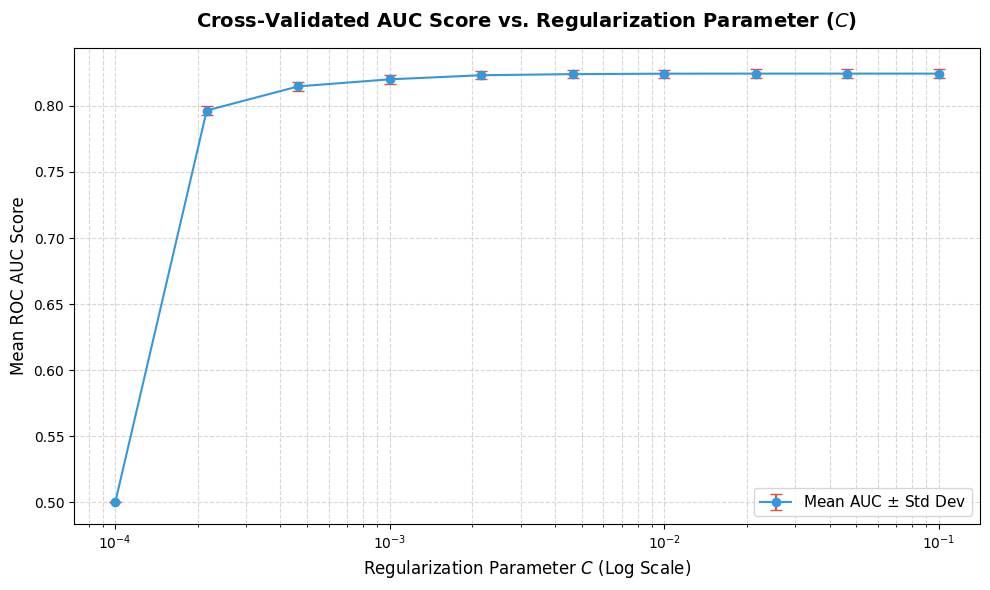

In [63]:
# Plotting the resulting AUCs on a graph

fig, ax = plt.subplots(figsize=(10, 6))

ax.errorbar(
    Cs,
    mean_aucs,
    yerr=std_aucs,
    fmt='-o',
    color='#3498db',       # Blue line is for the mean path
    ecolor='#e74c3c',      # Red is for the error bars
    elinewidth=1.5,
    capsize=4,
    label=r'Mean AUC $\pm$ Std Dev'
)

# Set the x-axis to a logarithmic scale due to np.logspace
ax.set_xscale('log')

# Labels and Styling
ax.set_title('Cross-Validated AUC Score vs. Regularization Parameter ($C$)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Regularization Parameter $C$ (Log Scale)', fontsize=12)
ax.set_ylabel('Mean ROC AUC Score', fontsize=12)
ax.grid(True, which="both", linestyle='--', alpha=0.5)
ax.legend(loc='lower right', fontsize=11)

plt.tight_layout()

In [64]:
# Performed LASSO regularization with the a manually input our C value such
# that we reduce as many variables as possible without sacrificing accuracy

print(f"LASSO regularized logistic regression with C={best_C_auc} based on AUC\n")

best_C_auc = 0.0022

final_auc_model = LogisticRegression(
    penalty='l1',
    solver='liblinear',
    C=best_C_auc,
    max_iter=1000,
    random_state=67
)
final_auc_model.fit(x_train_scaled, y_train)

coef = pd.Series(final_auc_model.coef_[0], index=feature_names)
selected = coef[coef != 0].sort_values(ascending=False)
unselected = coef[coef == 0]

print(f"\n  Lasso selected {len(selected)} out of {len(feature_names)} features.")
print(f"\n  Unselected features were\n{unselected}\n")
print(f"  {'Feature':<25}  {'Coefficient':>12}  {'Effect on Diabetes Risk'}")
print("  " + "-" * 65)
for feat, val in selected.items():
    direction = "↑ INCREASES risk" if val > 0 else "↓ decreases risk"
    print(f"  {feat:<25}  {val:>12.4f}  {direction}")

LASSO regularized logistic regression with C=0.021544346900318822 based on AUC


  Lasso selected 13 out of 21 features.

  Unselected features were
Smoker           0.0
PhysActivity     0.0
Fruits           0.0
Veggies          0.0
AnyHealthcare    0.0
NoDocbcCost      0.0
MentHlth         0.0
PhysHlth         0.0
dtype: float64

  Feature                     Coefficient  Effect on Diabetes Risk
  -----------------------------------------------------------------
  GenHlth                          0.5920  ↑ INCREASES risk
  BMI                              0.4762  ↑ INCREASES risk
  Age                              0.3889  ↑ INCREASES risk
  HighBP                           0.3561  ↑ INCREASES risk
  HighChol                         0.2644  ↑ INCREASES risk
  CholCheck                        0.1273  ↑ INCREASES risk
  Sex                              0.0796  ↑ INCREASES risk
  HeartDiseaseorAttack             0.0787  ↑ INCREASES risk
  DiffWalk                         0.0165  ↑ INCREAS

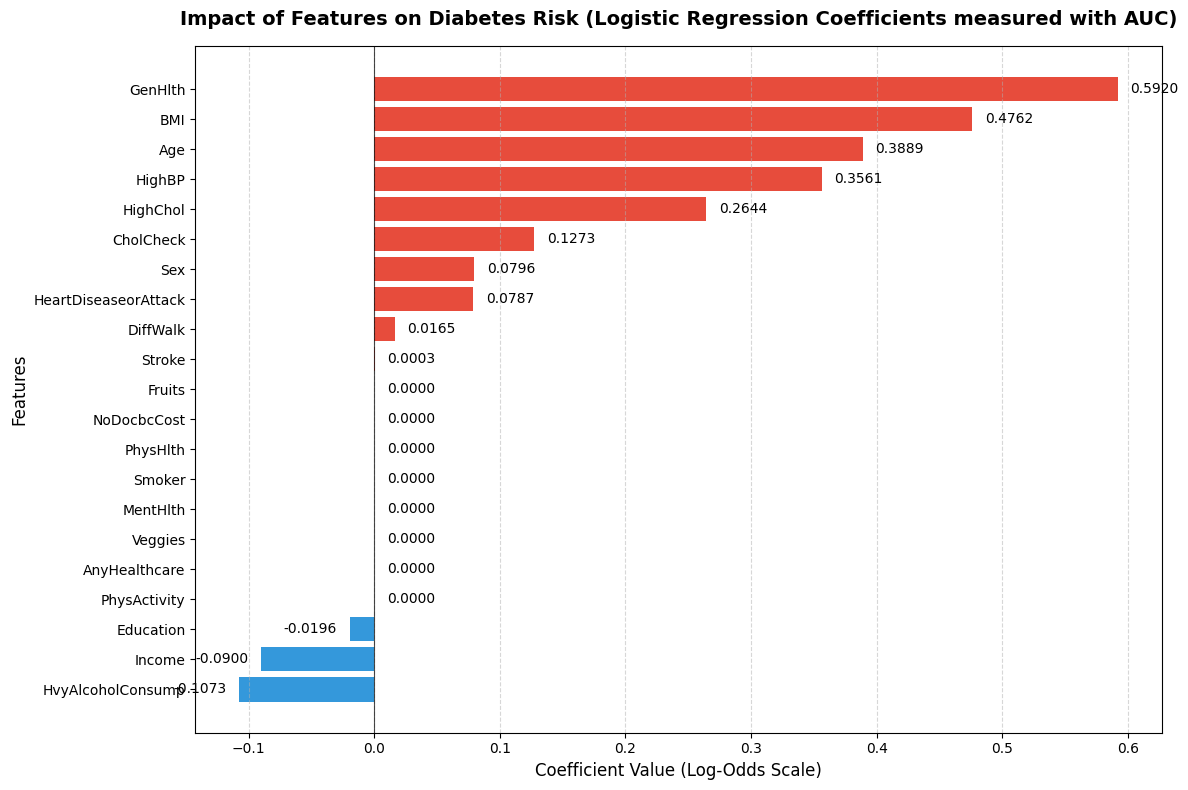

In [65]:
# Plot the coefficients of each feature in the LASSO regularized logistic model

coef_all = pd.Series(final_auc_model.coef_[0], index=feature_names).sort_values(ascending=True)

# 2. Define colors: Red for increasing risk (>0), Blue for decreasing risk (<0)
colors = ['#e74c3c' if val > 0 else '#3498db' for val in coef_all.values]

# 3. Create the horizontal bar plot
plt.figure(figsize=(12, 8))
bars = plt.barh(coef_all.index, coef_all.values, color=colors, edgecolor='none')

# 4. Add a vertical line at 0 for reference
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8, alpha=0.7)

# 5. Styling and labels
plt.title('Impact of Features on Diabetes Risk (Logistic Regression Coefficients measured with AUC)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Coefficient Value (Log-Odds Scale)', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)

# 6. Optional: Add value labels next to the bars for exact precision
for bar in bars:
    width = bar.get_width()
    # Position text based on whether it's positive or negative
    if width >= 0:
        plt.text(width + 0.01, bar.get_y() + bar.get_height()/2, f'{width:.4f}',
                 va='center', ha='left', fontsize=10, color='black')
    else:
        plt.text(width - 0.01, bar.get_y() + bar.get_height()/2, f'{width:.4f}',
                 va='center', ha='right', fontsize=10, color='black')

# 7. Prevent label truncation and display
plt.tight_layout()
plt.show()


CROSS VALIDATION USING ACCURACY

In [66]:
# Performed cross validation across 10 lambda values (regularization hyperparameter)
# (10^-4 to 10^-1 on a log scale) by maximizing the accuracy
# which is a measure of how many data points it guesses correctly

# From here we repeat the same process above as we did for AUC but for accuracy instead

mean_accs = np.zeros(len(Cs))
std_accs = np.zeros(len(Cs))
feature_counts = np.zeros(len(Cs))

print(f"\n  {'C':>8}  {'Mean Accuracy':>10}  {'Std Accuracy':>10}  {'# Features':>12}")
print("  " + "-" * 50)

best_C_acc, best_acc = None, 0
for i, C in enumerate(Cs):
    m = LogisticRegression(
        penalty='l1',         # L1 = Lasso regularization
        solver='liblinear',   # required solver for L1
        C=C,
        max_iter=1000,
        random_state=67
    )
    acc = cross_val_score(m, x_train_scaled, y_train, cv=5, scoring='accuracy')

    mean_accs[i] = acc.mean()
    std_accs[i] = acc.std()

    m.fit(x_train_scaled, y_train)
    n_features = (m.coef_[0] != 0).sum()
    feature_counts[i] = n_features
    print(f"  {round(C,4):>8}  {acc.mean():>10.4f}  {acc.std():>10.4f}  {n_features:>12}")
    if acc.mean() > best_acc:
        best_acc, best_C_acc = acc.mean(), C

print(f"\n  ✓ Best C = {best_C_acc} (CV ACC = {best_acc:.4f})")



         C  Mean Accuracy  Std Accuracy    # Features
  --------------------------------------------------
    0.0001      0.5000      0.0000             2
    0.0002      0.7188      0.0043             5
    0.0005      0.7379      0.0037             6
     0.001      0.7426      0.0035            11
    0.0022      0.7459      0.0030            12
    0.0046      0.7466      0.0026            18
      0.01      0.7469      0.0028            19
    0.0215      0.7469      0.0031            20
    0.0464      0.7468      0.0031            21
       0.1      0.7467      0.0031            21

  ✓ Best C = 0.01 (CV ACC = 0.7469)


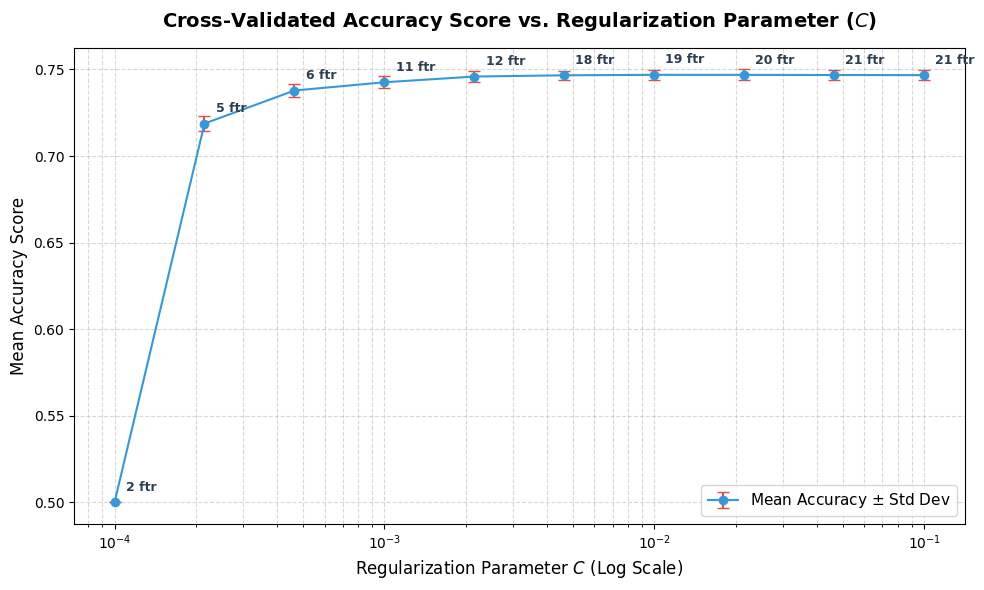

In [67]:
# Plotting the resulting accuracy values on a graph

fig, ax = plt.subplots(figsize=(10, 6))

ax.errorbar(
    Cs,
    mean_accs,
    yerr=std_accs,
    fmt='-o',
    color='#3498db',       # Blue line for the mean path
    ecolor='#e74c3c',      # Red color for the error bars
    elinewidth=1.5,
    capsize=4,
    label=r'Mean Accuracy $\pm$ Std Dev'
)

for c_val, acc_val, num_feats in zip(Cs, mean_accs, feature_counts.astype(int)):
    ax.annotate(
        f'{num_feats} ftr',
        xy=(c_val, acc_val),
        textcoords="offset points",
        xytext=(8, 6),         # Shifts text 8 pixels right and 6 pixels up from the dot
        ha='left',
        va='bottom',
        fontsize=9,
        fontweight='bold',
        color='#2c3e50'
    )

# Set the x-axis to a logarithmic scale due to np.logspace
ax.set_xscale('log')

# Labels and Styling
ax.set_title('Cross-Validated Accuracy Score vs. Regularization Parameter ($C$)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Regularization Parameter $C$ (Log Scale)', fontsize=12)
ax.set_ylabel('Mean Accuracy Score', fontsize=12)
ax.grid(True, which="both", linestyle='--', alpha=0.5)
ax.legend(loc='lower right', fontsize=11)

plt.tight_layout()

In [68]:
# Performed LASSO regularization with the a manually input our C value such
# that we reduce as many variables as possible without sacrificing accuracy

print(f"LASSO regularized logistic regression with C={best_C_acc} based on Accuracy\n")

best_C_acc = 0.0021544

final_acc_model = LogisticRegression(
    penalty='l1',
    solver='liblinear',
    C=best_C_acc,
    max_iter=1000,
    random_state=67
)
final_acc_model.fit(x_train_scaled, y_train)

coef = pd.Series(final_acc_model.coef_[0], index=feature_names)
selected = coef[coef != 0].sort_values(ascending=False)
unselected = coef[coef == 0]

print(f"\n  Lasso selected {len(selected)} out of {len(feature_names)} features.")
print(f"\n  Unselected features were\n{unselected}\n")
print(f"  {'Feature':<25}  {'Coefficient':>12}  {'Effect on Diabetes Risk'}")
print("  " + "-" * 65)
for feat, val in selected.items():
    direction = "↑ INCREASES risk" if val > 0 else "↓ decreases risk"
    print(f"  {feat:<25}  {val:>12.4f}  {direction}")

LASSO regularized logistic regression with C=0.01 based on Accuracy


  Lasso selected 12 out of 21 features.

  Unselected features were
Smoker           0.0
Stroke           0.0
PhysActivity     0.0
Fruits           0.0
Veggies          0.0
AnyHealthcare    0.0
NoDocbcCost      0.0
MentHlth         0.0
PhysHlth         0.0
dtype: float64

  Feature                     Coefficient  Effect on Diabetes Risk
  -----------------------------------------------------------------
  GenHlth                          0.5917  ↑ INCREASES risk
  BMI                              0.4750  ↑ INCREASES risk
  Age                              0.3881  ↑ INCREASES risk
  HighBP                           0.3559  ↑ INCREASES risk
  HighChol                         0.2638  ↑ INCREASES risk
  CholCheck                        0.1260  ↑ INCREASES risk
  Sex                              0.0785  ↑ INCREASES risk
  HeartDiseaseorAttack             0.0783  ↑ INCREASES risk
  DiffWalk                         0.0163 

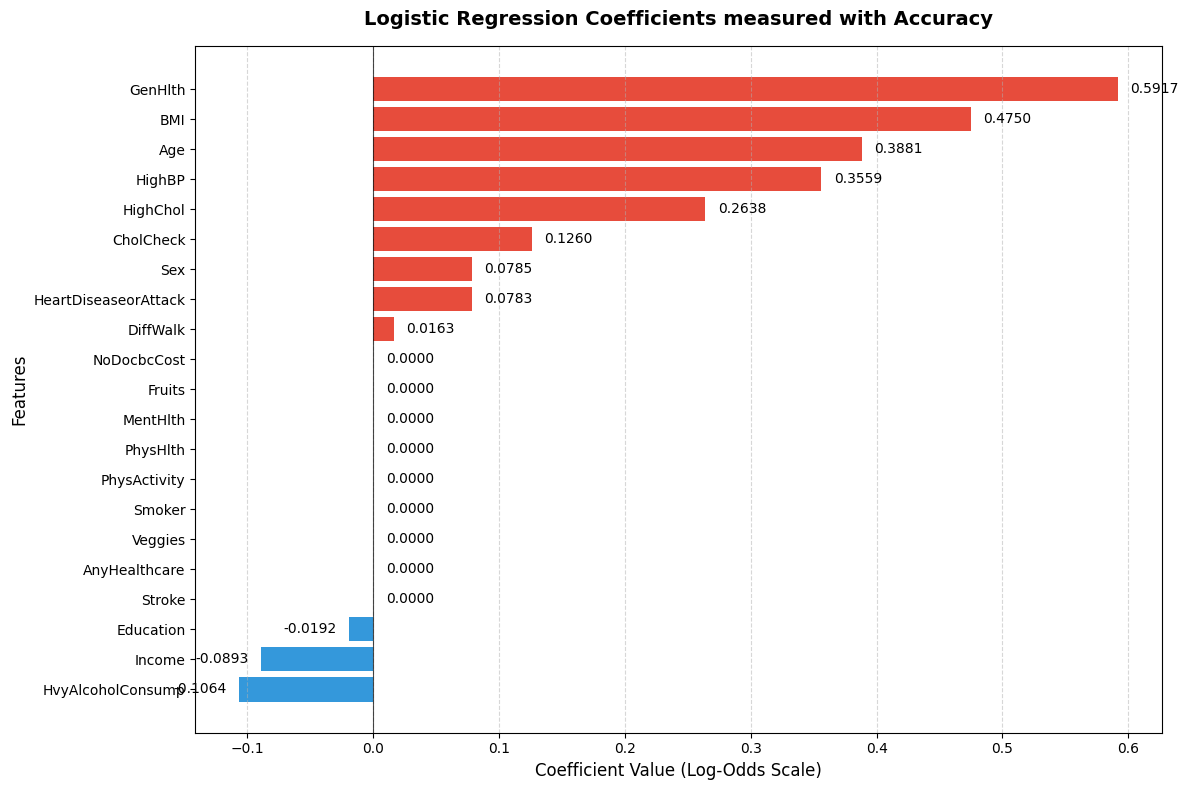

In [69]:
# Plot the coefficients of each feature in the LASSO regularized logistic model

coef_all = pd.Series(final_acc_model.coef_[0], index=feature_names).sort_values(ascending=True)

# 2. Define colors: Red for increasing risk (>0), Blue for decreasing risk (<0)
colors = ['#e74c3c' if val > 0 else '#3498db' for val in coef_all.values]

# 3. Create the horizontal bar plot
plt.figure(figsize=(12, 8))
bars = plt.barh(coef_all.index, coef_all.values, color=colors, edgecolor='none')

# 4. Add a vertical line at 0 for reference
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8, alpha=0.7)

# 5. Styling and labels
plt.title('Logistic Regression Coefficients measured with Accuracy', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Coefficient Value (Log-Odds Scale)', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)

# 6. Optional: Add value labels next to the bars for exact precision
for bar in bars:
    width = bar.get_width()
    # Position text based on whether it's positive or negative
    if width >= 0:
        plt.text(width + 0.01, bar.get_y() + bar.get_height()/2, f'{width:.4f}',
                 va='center', ha='left', fontsize=10, color='black')
    else:
        plt.text(width - 0.01, bar.get_y() + bar.get_height()/2, f'{width:.4f}',
                 va='center', ha='right', fontsize=10, color='black')

# 7. Prevent label truncation and display
plt.tight_layout()
plt.show()